In [4]:
import sys
from pathlib import Path

# Add repo root to Python path (…/unified-probabilistic-validation)
repo_root = Path.cwd().parent  # if you're running from notebooks/
sys.path.insert(0, str(repo_root))

print("Repo root added:", repo_root)

Repo root added: c:\Users\jiaya\OneDrive\Documents\Lund_2025\Thesis\unified-probabilistic-validation


In [5]:
import numpy as np
from scipy.stats import norm

from src.calibration.pit import compute_pit, pit_uniformity_test
from src.scoring.crps import crps_sample

# Generate synthetic correct model
np.random.seed(42)

n = 1000
y_true = np.random.normal(0, 1, n)

# Assume model predicts true distribution
cdf_values = norm.cdf(y_true, loc=0, scale=1)

pit_values = compute_pit(cdf_values)

print(pit_uniformity_test(pit_values))

{'ks_statistic': np.float64(0.017327787320720822), 'p_value': np.float64(0.9196626608357358)}


In [ ]:
# to check Misspecified models

def run_test(loc, scale):
    cdf_vals = norm.cdf(y_true, loc=loc, scale=scale)
    u = compute_pit(cdf_vals)
    return pit_uniformity_test(u)

print("Under-dispersed (sigma=0.5):", run_test(0, 0.5))
print("Over-dispersed (sigma=1.5):", run_test(0, 1.5))
print("Biased mean (+0.5):", run_test(0.5, 1))

Under-dispersed (sigma=0.5): {'ks_statistic': np.float64(0.16124761893302308), 'p_value': np.float64(3.489188542950653e-23)}
Over-dispersed (sigma=1.5): {'ks_statistic': np.float64(0.11044491259716649), 'p_value': np.float64(4.4389336638688297e-11)}
Biased mean (+0.5): {'ks_statistic': np.float64(0.20665165497919608), 'p_value': np.float64(6.245416410669392e-38)}


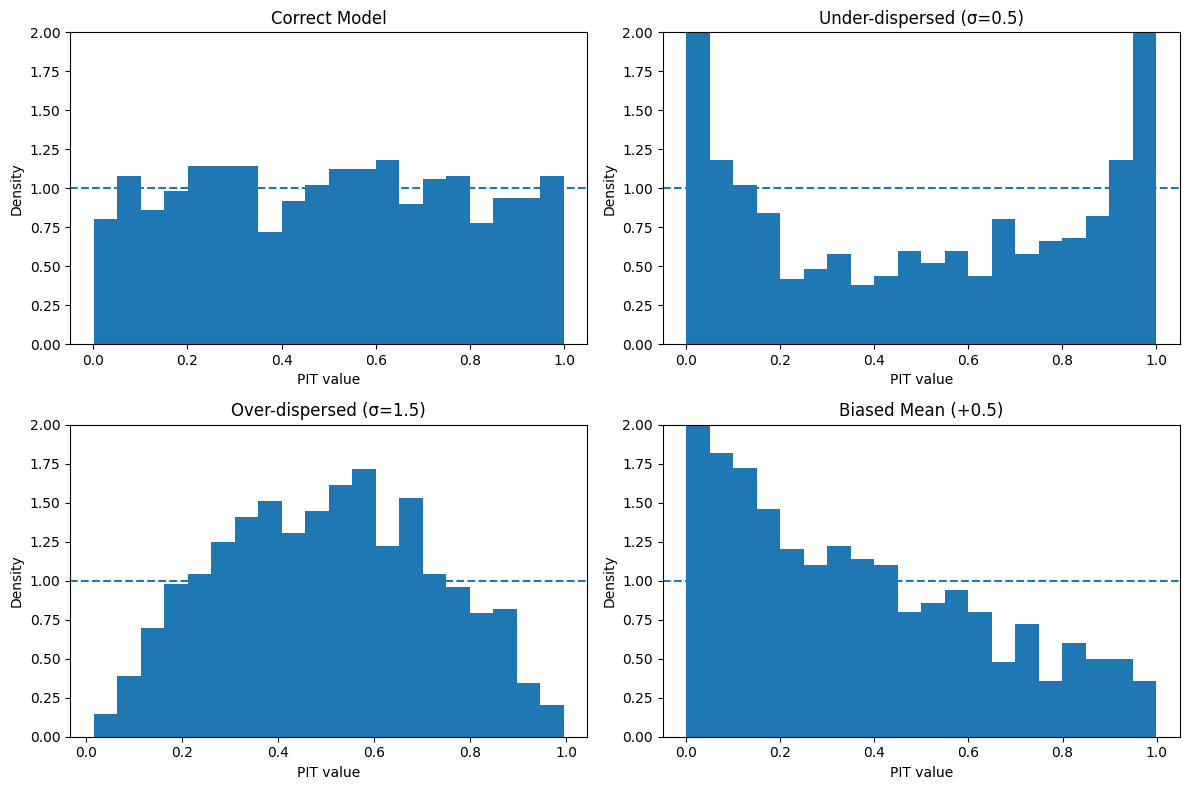

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def compute_u(loc, scale):
    cdf_vals = norm.cdf(y_true, loc=loc, scale=scale)
    return compute_pit(cdf_vals)

cases = [
    ("Correct Model", 0, 1),
    ("Under-dispersed (σ=0.5)", 0, 0.5),
    ("Over-dispersed (σ=1.5)", 0, 1.5),
    ("Biased Mean (+0.5)", 0.5, 1),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (title, loc, scale) in zip(axes.flatten(), cases):
    u = compute_u(loc, scale)
    ax.hist(u, bins=20, density=True)
    ax.axhline(1, linestyle="--")  # uniform reference line
    ax.set_title(title)
    ax.set_ylim(0, 2)
    ax.set_xlabel("PIT value")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from scipy.stats import norm
from src.scoring.crps import crps_sample

def crps_for_case(loc, scale, n_samples=2000):
    # predictive distribution: N(loc, scale) for each observation
    # for CRPS sample approximation, draw samples for each y_t
    # we will draw samples per observation (vectorized via broadcasting)
    samples = np.random.normal(loc=loc, scale=scale, size=(len(y_true), n_samples))
    crps_vals = [crps_sample(samples[i], y_true[i]) for i in range(len(y_true))]
    return float(np.mean(crps_vals))

cases = [
    ("Correct", 0, 1),
    ("Under-dispersed (0.5)", 0, 0.5),
    ("Over-dispersed (1.5)", 0, 1.5),
    ("Biased mean (+0.5)", 0.5, 1),
]

for name, loc, scale in cases:
    print(name, "Mean CRPS:", crps_for_case(loc, scale, n_samples=500))

Correct Mean CRPS: 0.5537363295768994
Under-dispersed (0.5) Mean CRPS: 0.595002837962049
Over-dispersed (1.5) Mean CRPS: 0.5847555158406386
Biased mean (+0.5) Mean CRPS: 0.6197207037662973


# Synthetic Validation: Calibration and Scoring Sanity Check

## 1. Objective

This notebook verifies the correctness of the probabilistic validation framework under controlled synthetic conditions.

Data-generating process:

$
y_t \sim \mathcal{N}(0,1)
$

Predictive distributions are intentionally specified as:

* Correct model: $ \mathcal{N}(0,1) $
* Under-dispersed: $ \mathcal{N}(0,0.5^2) $
* Over-dispersed: $ \mathcal{N}(0,1.5^2) $
* Biased mean: $ \mathcal{N}(0.5,1) $

Sample size: **n = 1000**

---

## 2. PIT Uniformity (Kolmogorov–Smirnov Test)

| Model                   | KS Statistic | p-value  | Interpretation                       |
| ----------------------- | ------------ | -------- | ------------------------------------ |
| Correct                 | 0.0173       | 0.9197   | Cannot reject uniformity             |
| Under-dispersed (σ=0.5) | 0.1612       | 3.49e−23 | Strong deviation (U-shaped PIT)      |
| Over-dispersed (σ=1.5)  | 0.1104       | 4.44e−11 | Significant deviation (∩-shaped PIT) |
| Biased mean (+0.5)      | 0.2067       | 6.25e−38 | Severe deviation (skewed PIT)        |

### Interpretation

* The correctly specified model produces PIT values statistically indistinguishable from Uniform(0,1).
* Variance misspecification results in symmetric deviations.
* Mean bias produces asymmetric PIT distortion.
* The PIT-based uniformity test correctly identifies all forms of misspecification.

This validates the implementation of `compute_pit()` and `pit_uniformity_test()`.

---

## 3. CRPS Evaluation

Mean CRPS across models:

| Model                 | Mean CRPS  |
| --------------------- | ---------- |
| Correct               | **0.5537** |
| Under-dispersed (0.5) | 0.5950     |
| Over-dispersed (1.5)  | 0.5848     |
| Biased mean (+0.5)    | 0.6197     |

### Interpretation

* The correctly specified model achieves the lowest CRPS.
* Both variance miscalibration and mean bias increase CRPS.
* Mean bias produces the largest degradation.
* CRPS ranking aligns with theoretical optimality under proper scoring rules.

This confirms correct implementation of `crps_sample()`.

---

## 4. Diagnostic Shape Interpretation

The PIT histograms exhibit canonical patterns:

* **Correct model:** approximately uniform.
* **Under-dispersed:** U-shaped.
* **Over-dispersed:** ∩-shaped.
* **Biased mean:** skewed.

These patterns match classical calibration diagnostics.

---

## 5. Conclusion

The synthetic experiment verifies that:

1. PIT computation behaves correctly under known distributions.
2. The KS-based uniformity test identifies dispersion and bias errors.
3. CRPS is minimized under correct model specification.
4. The validation stack is statistically sound.

Therefore:

> The probabilistic calibration and scoring framework is internally consistent and theoretically validated under controlled conditions.

This provides a methodological foundation for applying the same diagnostics to real-world energy market models.
